/Users/annisa/micromamba/envs/scales/lib/python3.11/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/Users/annisa/micromamba/envs/scales/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


[svd] Using full-gene log-norm matrix (6574 genes)
[svd] Fold 0: 9525 cells × 6574 HVGs
[svd] Fold 1: 9525 cells × 6574 HVGs
[svd] Fold 2: 9524 cells × 6574 HVGs
[svd] Fold 3: 9524 cells × 6574 HVGs
[svd] Fold 4: 9524 cells × 6574 HVGs
[svd] Fold 5: 9524 cells × 6574 HVGs
[svd] SVD outputs saved → /Users/annisa/Desktop/dea-et-al-2026/results/anc_preloadh5ad/svd
[micdf] Fold 0 complete
[micdf] Fold 1 complete
[micdf] Fold 2 complete
[micdf] Fold 3 complete
[micdf] Fold 4 complete
[micdf] Fold 5 complete
[micdf] CSVs saved → /Users/annisa/Desktop/dea-et-al-2026/results/anc_preloadh5ad/micdf
[plot] Figure saved → /Users/annisa/Desktop/dea-et-al-2026/results/anc_preloadh5ad/micdf/micdf_plot.pdf


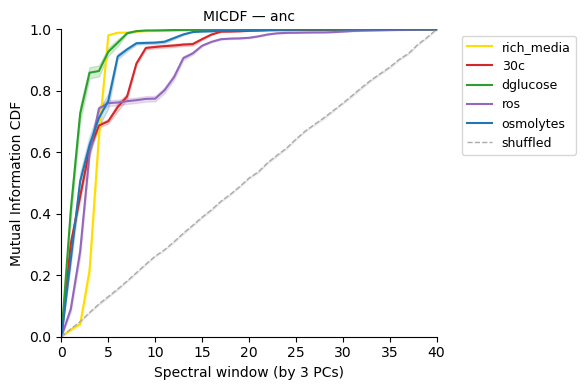

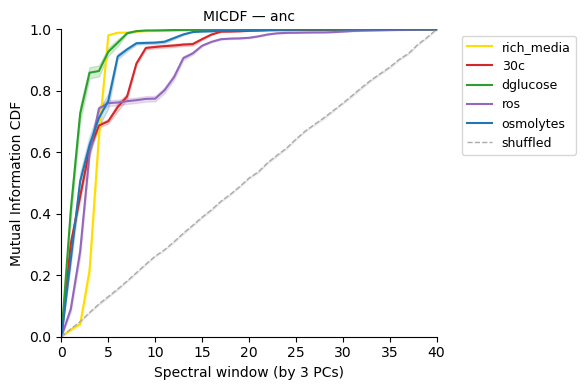

In [17]:
import scanpy as sc
import numpy as np
from scales.micdf import run_svd_folds, compute_micdf, plot_micdf

# Load your existing processed h5ad
adata = sc.read_h5ad("/Users/annisa/Box Sync/G7/scales_run_ipynb/anc_nova_CRSCfiltered.h5ad")


sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata          # ← SCALES reads from here
# everything below is only for UMAP/visualization, NOT for SCALES
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=1000, svd_solver='arpack')

# Add shuffled if not already present
if 'shuffled' not in adata.obs.columns:
    adata.obs['shuffled'] = np.random.randint(0, 2, size=len(adata))

# Run from SVD onward
out_dir = "/Users/annisa/Desktop/dea-et-al-2026/results/anc_preloadh5ad"
run_svd_folds(adata, output_dir=f"{out_dir}/svd")
mean_micdf, ste_micdf = compute_micdf(adata, svd_dir=f"{out_dir}/svd", output_dir=f"{out_dir}/micdf")
plot_micdf(mean_micdf, ste_micdf, output_path=f"{out_dir}/micdf/micdf_plot.pdf", title="MICDF — anc")